In [1]:
import pandas as pd
import numpy as np

In [2]:
heart_df = pd.read_csv("heart.csv")
heart_df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [3]:
heart_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [8]:
X = heart_df.drop(columns=['target'], axis=0)
y = heart_df['target']

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

In [11]:
from sklearn.neural_network import MLPClassifier
mlp_clf = MLPClassifier(hidden_layer_sizes=(10,10))
mlp_clf.fit(X_train, y_train)

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=(10, 10))

In [12]:
insurance = pd.read_csv("insurance.csv")
insurance.head()

,age,sex,bmi,children,smoker,charges
0,19,0,27.900,0,1,16884.92400
1,18,1,33.770,1,0,1725.55230
2,28,1,33.000,3,0,4449.46200
3,33,1,22.705,0,0,21984.47061
4,32,1,28.880,0,0,3866.85520


In [17]:
insurance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   int64  
 2   bmi       1335 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   int64  
 5   charges   1338 non-null   float64
dtypes: float64(2), int64(4)
memory usage: 62.8 KB


In [25]:
insurance = insurance.dropna()
X2 = insurance.drop(columns=['charges'], axis=0)
y2=insurance['charges']

In [26]:
from sklearn.model_selection import train_test_split

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2)

In [31]:
from sklearn.neural_network import MLPRegressor
mlp_reg = MLPRegressor(hidden_layer_sizes=(10,10))
mlp_reg.fit(X_train2, y_train2)

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPRegressor(hidden_layer_sizes=(10, 10))

### Creating kernel explainers


MLPRegressor

In [32]:
import shap
explainer = shap.KernelExplainer(
    # Model's Prediction function,,
    mlp_reg.predict,
    # Representative summary of dataset
    shap.kmeans(X2, 10)
)
shap_values_reg = explainer.shap_values(X2)

  0%|          | 0/1335 [00:00<?, ?it/s]

MLPClassifier

In [33]:
import shap

explainer = shap.KernelExplainer(
    # Model's prediction function,
    mlp_clf.predict_proba,
    shap.kmeans(X, 10)
    # Representative summary of dataset
)
shap_values_cls = explainer.shap_values(X)

  0%|          | 0/1025 [00:00<?, ?it/s]

### Feature importance

- MLPRegressor

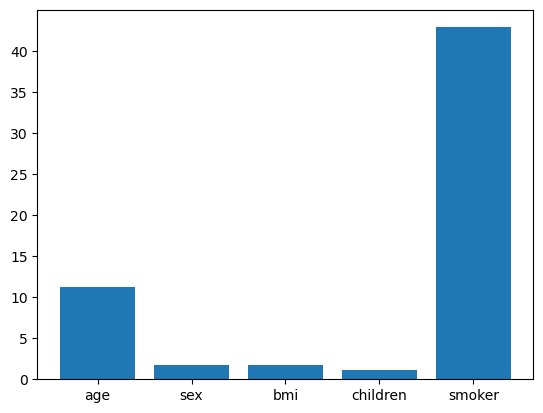

In [36]:
import numpy as np
import matplotlib.pyplot as plt
mean_reg = np.abs(shap_values_reg.mean(axis=0))
plt.bar(X2.columns, mean_reg)
plt.show()

- MLPClassifier

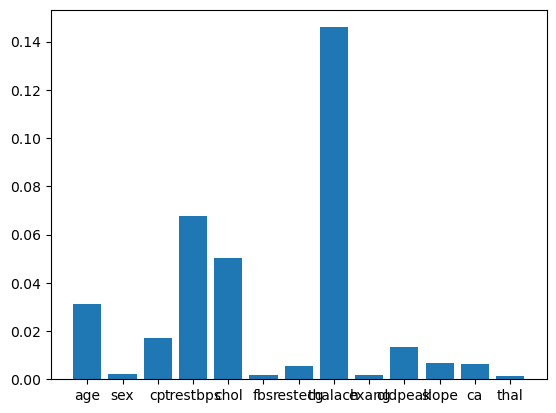

In [37]:
mean_cls = np.abs(shap_values_cls[:,:, 1]).mean(axis=0)
plt.bar(X.columns, mean_cls)
plt.show()

### Comparing with model-specific approaches

In [38]:
# Linear regression
plt.bar(X2.columns, np.abs(lin_reg.coef_))
plt.show()

NameError: name 'lin_reg' is not defined

In [ ]:
# Logistic regression
plt.bar(X.columns, np.abs(log_reg.coef_))

Exercise: 
- Kernel explainer for MLPRegressor

In [41]:
import shap

# Create a SHAP Kernel Explainer
explainer = shap.KernelExplainer(
    model.predict,
    shap.kmeans(X, 10)
)

# Calculate SHAP values
shap_values = explainer.shap_values(X)

# Calculate mean absolute SHAP values
mean_abs_shap = np.abs(shap_values.mean(axis=0))

plt.bar(X.columns, mean_abs_shap)
plt.title('Mean Absolute SHAP Values for MLPRegressor')
plt.xticks(rotation=45)
plt.show()

Provided model function fails when applied to the provided data set.


ValueError: X has 13 features, but MLPRegressor is expecting 5 features as input.

- Kernel explainer for MLPClassifier

In [42]:
import shap

# Create a SHAP Kernel Explainer
explainer = shap.KernelExplainer(
    model.predict_proba,
    shap.kmeans(X, 10)
)

# Calculate SHAP values
shap_values = explainer.shap_values(X)

# Calculate mean absolute SHAP values
mean_abs_shap = np.abs(shap_values[:, :, 1]).mean(axis=0)

plt.bar(X.columns, mean_abs_shap)
plt.title('Mean Absolute SHAP Values for MLPClassifier')
plt.xticks(rotation=45)
plt.show()

AttributeError: 'MLPRegressor' object has no attribute 'predict_proba'

## SHAP vs. model-specific approaches

In [ ]:
import shap

# Extract model coefficients
coefficients = model.coef_[0]

# Compute SHAP values
explainer = shap.KernelExplainer(
    model.predict_proba,
    shap.kmeans(X, 10)
)
shap_values = explainer.shap_values(X)

# Calculate mean absolute SHAP values
mean_abs_shap = np.abs(shap_values[:, :, 1]).mean(axis=0)

plot_importances(coefficients, mean_abs_shap)

### Visualizing SHAP explainability

In [48]:
insurance = pd.read_csv("insurance.csv")
insurance.head(10)

,age,sex,bmi,children,smoker,charges
0,19,0,27.900,0,1,16884.92400
1,18,1,33.770,1,0,1725.55230
2,28,1,33.000,3,0,4449.46200
3,33,1,22.705,0,0,21984.47061
4,32,1,28.880,0,0,3866.85520
5,31,0,25.740,0,0,3756.62160
6,46,0,33.440,1,0,8240.58960
7,37,0,27.740,3,0,7281.50560
8,37,1,29.830,2,0,6406.41070
9,60,0,25.840,0,0,28923.13692


In [50]:
insurance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   int64  
 2   bmi       1335 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   int64  
 5   charges   1338 non-null   float64
dtypes: float64(2), int64(4)
memory usage: 62.8 KB


In [52]:
X = insurance.drop(columns=["charges"], axis=0)
y = insurance['charges']

In [54]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [56]:
from sklearn.neural_network import MLPRegressor
model = MLPRegressor(hidden_layer_sizes=(10,10))
model.fit(X_train, y_train)


ValueError: Input X contains NaN.
MLPRegressor does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
import shap
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

### Feature importance plot
- Shows contribution of each feature on model output


In [ ]:
shap.summary_plot(shap_values, X, plot_type="bar")

### Beaswarm plot
- Shows SHAP values distribution
- Highlights direction and magnitude of each feature on prediction
    - Red color -> High feature value
    - Blue color -> low feature value
    - SHAP value > 0 -> increases outcome
    - SHAP value < 0 -> decreases outcome


In [ ]:
shap.summary_plot(shap_values, X, plot_type="dot")

### Partial Dependence plot
- Shows relationship between feature and predicted outcome
- Shows feature's impact across its range
- Verifies if relationship is as expected

### Partial dependence plot

- For each sample:
    - Vary value of selected feature
    - Hold other features constant
    - Predict outcome
- Average results from all samples

In [57]:
shap.partial_dependence_plot("age", model.predict, X)

ValueError: Input X contains NaN.
MLPRegressor does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

### Feature Importance plots for admissions analysis

In [ ]:
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

# Derive shap values
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_train)

# Plot the feature importance plot
shap.summary_plot(shap_values, X_train, plot_type="bar")

### Analyzing feature effects with beeswarm plots

In [ ]:
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

# Derive shap values
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_train)

# Plot the beeswarm plot
shap.summary_plot(shap_values, X_train, plot_type="dot")

### Assessing impact with partial dependence plots

In [ ]:
from sklearn.ensemble import RandomForestRegressor
import shap

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

# Generate the partial dependence plot for CGPA
shap.partial_dependence_plot("CGPA", model.predict, X_train)

#### Assessing impact with partial dependence plots


In [ ]:
from sklearn.ensemble import RandomForestRegressor
import shap

model = RandomForestRegressor(random_state=42)

# Train the model
model.fit(X_train, y_train)

# Generate the partial dependence plot for University Rating
shap.partial_dependence_plot("University Rating", model.predict, X_train)